# <center> Homework 131

In [38]:
import tf_model 
import tf_data
from importlib import reload
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Load Data

In [2]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] 
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) 
df = df.drop_duplicates() 

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

In [3]:
df_mulvar = df[["bus", "rail"]] / 1e6
df_mulvar["next_day_type"] = df["day_type"].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar).astype(np.float32)

df_mulvar.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [43]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":'2019-12']

## Task 1 
да се имплментира класа RNN

## Task 2
да се имплментира класа SimpleRNNCell

In [14]:
reload(tf_data)
from tf_data import Dataset

seq_length = 56

def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None, cache_fname=None):
                                
    ds = to_windows(Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, target_col]))
    
    if cache_fname is not None:
        ds = ds.cache(cache_fname)

    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    return ds.batch(batch_size)

In [15]:
reload(tf_data)

seq2seq_train_cus = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42, cache_fname='cache/seq2seq_model_train_cache.pkl')
seq2seq_valid_cus = to_seq2seq_dataset(mulvar_valid, cache_fname='cache/seq2seq_model_valid_cache.pkl')

In [ ]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, SimpleRNNCell 


custom_ln_model = Sequential([
    Input([None, 5]),
    RNN(SimpleRNNCell(32), return_sequences=True),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

2026-02-18 13:50:56.840719: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a90e8025310 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-18 13:50:56.840746: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1771415457.055360    7802 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
33it [00:06,  4.90it/s]


    - loss: 0.350 - meanabsolutepercentageerror: 0.609
    - val_loss: 0.185 - val_meanabsolutepercentageerror: 0.468
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.052 - meanabsolutepercentageerror: 0.110
    - val_loss: 0.052 - val_meanabsolutepercentageerror: 0.136
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 13.58it/s]


    - loss: 0.051 - meanabsolutepercentageerror: 0.109
    - val_loss: 0.058 - val_meanabsolutepercentageerror: 0.150
    - Learning Rate: 0.001
Epoch 20/20


33it [00:02, 13.74it/s]


    - loss: 0.051 - meanabsolutepercentageerror: 0.108
    - val_loss: 0.053 - val_meanabsolutepercentageerror: 0.138
    - Learning Rate: 0.001


## Task 3
да се имплментира класа LayerNormalization

In [ ]:
x = tf.random.uniform([2, 5])
x = tf.cast(x, tf.float32)

reload(tf_model)
from tf_model import Input, LayerNormalization

LN_custom = LayerNormalization()(Input(x.shape[1:]))

LN_original =  tf.keras.layers.LayerNormalization()
LN_original.build(x.shape)

out_custom = LN_custom.call(x)
out_keras  = LN_original(x)

tf.reduce_mean(out_custom - out_keras).numpy() # -0.00000008568168

np.float32(-8.568168e-08)

## Task 4
да се имплментира класа LNSimpleRNNCell чрез наследяване на SimpleRNNCell

In [59]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, LNSimpleRNNCell 

custom_ln_model = Sequential([
    Input([None, 5]),
    RNN(LNSimpleRNNCell(32), return_sequences=True),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:07,  4.14it/s]


    - loss: 0.388 - meanabsolutepercentageerror: 0.701
    - val_loss: 0.184 - val_meanabsolutepercentageerror: 0.471
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.060 - meanabsolutepercentageerror: 0.125
    - val_loss: 0.061 - val_meanabsolutepercentageerror: 0.158
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 11.50it/s]


    - loss: 0.060 - meanabsolutepercentageerror: 0.126
    - val_loss: 0.058 - val_meanabsolutepercentageerror: 0.152
    - Learning Rate: 0.001
Epoch 20/20


33it [00:02, 12.42it/s]


    - loss: 0.057 - meanabsolutepercentageerror: 0.121
    - val_loss: 0.063 - val_meanabsolutepercentageerror: 0.162
    - Learning Rate: 0.001


## Task 5
да се имплментира класа DroputSimpleRNNCell

In [7]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, DropoutSimpleRNNCell 

custom_ln_model = Sequential([
    Input([None, 5]),
    RNN(DropoutSimpleRNNCell(32, dropout=0.2, recurrent_dropout=0.1), return_sequences=True),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

2026-02-18 17:00:03.792694: I external/local_xla/xla/service/service.cc:163] XLA service 0x7483a4045070 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-18 17:00:03.792951: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1771426804.086293    4515 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
33it [00:07,  4.33it/s]


    - loss: 0.551 - meanabsolutepercentageerror: 0.929
    - val_loss: 0.253 - val_meanabsolutepercentageerror: 0.590
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.078 - meanabsolutepercentageerror: 0.161
    - val_loss: 0.078 - val_meanabsolutepercentageerror: 0.203
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 11.95it/s]


    - loss: 0.078 - meanabsolutepercentageerror: 0.160
    - val_loss: 0.074 - val_meanabsolutepercentageerror: 0.194
    - Learning Rate: 0.001
Epoch 20/20


33it [00:02, 13.05it/s]


    - loss: 0.075 - meanabsolutepercentageerror: 0.156
    - val_loss: 0.053 - val_meanabsolutepercentageerror: 0.145
    - Learning Rate: 0.001


## Task 6
да се тества примера с layer normalizatoin

    с оригиналните класове
    с нашата имплементация


In [8]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units, activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [10]:
def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                                batch_size=32, shuffle=False, seed=None):
                                
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, 1]))
    
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    
    return ds.batch(batch_size)

seq2seq_train_org = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid_org = to_seq2seq_dataset(mulvar_valid)

In [11]:
custom_ln_model = tf.keras.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True,
    input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_org, epochs=20, validation_data=(seq2seq_valid_org))

Epoch 1/20


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


     31/Unknown 5s 42ms/step - loss: 0.6230 - mape: 104.7089

2026-02-18 17:06:45.165287: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.4552 - mape: 78.7060 - val_loss: 0.2051 - val_mape: 49.4565
Epoch 2/20
 1/33 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - loss: 0.1933 - mape: 34.3318

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0967 - mape: 20.5829 - val_loss: 0.0981 - val_mape: 26.4622
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0864 - mape: 18.0289 - val_loss: 0.0871 - val_mape: 22.9511
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0798 - mape: 16.3943 - val_loss: 0.0883 - val_mape: 22.7305
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0749 - mape: 15.3175 - val_loss: 0.0800 - val_mape: 20.6346
Epoch 9/20
 1/33 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0640 - mape: 11.0955

2026-02-18 17:06:57.173903: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0716 - mape: 14.6409 - val_loss: 0.0747 - val_mape: 19.1481
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0685 - mape: 13.9978 - val_loss: 0.0698 - val_mape: 18.0505
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0664 - mape: 13.6017 - val_loss: 0.0719 - val_mape: 18.6249
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - loss: 0.0645 - mape: 13.2770 - val_loss: 0.0659 - val_mape: 16.9754
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0625 - mape: 12.8514 - val_loss: 0.0656 - val_mape: 16.9216
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0610 - mape: 12.6173 - val_loss: 0.0658 - val_mape: 17.1948
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0591 - mape: 12.2946 - val_loss: 0.0653 - val_mape: 17.0232
Epoch 16/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0588 - mape: 12.2553 - val_loss: 0.0599 - val_mape: 15.7702
Epoch 17/20
 1/33 ━━━━━━━━━━━━━━━━━

2026-02-18 17:07:12.549781: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0572 - mape: 11.9628 - val_loss: 0.0602 - val_mape: 15.9261
Epoch 18/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0565 - mape: 11.8482 - val_loss: 0.0554 - val_mape: 14.7648
Epoch 19/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0554 - mape: 11.6622 - val_loss: 0.0591 - val_mape: 15.4668
Epoch 20/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0547 - mape: 11.5249 - val_loss: 0.0561 - val_mape: 14.8898


In [12]:
mae_org, *_ = custom_ln_model.evaluate(seq2seq_valid_org)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0561 - mape: 14.8898


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [20]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, LNSimpleRNNCell 

custom_ln_model = Sequential([
    Input([None, 5]),
    RNN(LNSimpleRNNCell(32), return_sequences=True),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:12,  2.74it/s]


    - loss: 0.384 - meanabsolutepercentageerror: 0.690
    - val_loss: 0.197 - val_meanabsolutepercentageerror: 0.491
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.060 - meanabsolutepercentageerror: 0.124
    - val_loss: 0.059 - val_meanabsolutepercentageerror: 0.151
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 11.26it/s]


    - loss: 0.058 - meanabsolutepercentageerror: 0.122
    - val_loss: 0.066 - val_meanabsolutepercentageerror: 0.166
    - Learning Rate: 0.001
Epoch 20/20


33it [00:04,  8.04it/s]


    - loss: 0.058 - meanabsolutepercentageerror: 0.121
    - val_loss: 0.051 - val_meanabsolutepercentageerror: 0.133
    - Learning Rate: 0.001


In [21]:
mae_cus, *_ = custom_ln_model.evaluate(seq2seq_valid_cus)

    - loss: 0.051408544182777405 - meanabsolutepercentageerror: 0.1327781230211258


In [23]:
pd.Series([mae_org, mae_cus.numpy()], ['Original', 'Custom'], name='MAE') * 1e6

Original    56100.908667
Custom      51408.544183
Name: MAE, dtype: float64

## Task 7
да се добавят параметри dropout и recurrent_dropout на класовете RNN и SimpleRNN

In [24]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, SimpleRNNCell 

custom_ln_model = Sequential([
    Input([None, 5]),
    RNN(SimpleRNNCell(32), return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:07,  4.67it/s]


    - loss: 0.492 - meanabsolutepercentageerror: 0.849
    - val_loss: 0.210 - val_meanabsolutepercentageerror: 0.482
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.081 - meanabsolutepercentageerror: 0.166
    - val_loss: 0.075 - val_meanabsolutepercentageerror: 0.196
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 12.33it/s]


    - loss: 0.079 - meanabsolutepercentageerror: 0.161
    - val_loss: 0.061 - val_meanabsolutepercentageerror: 0.167
    - Learning Rate: 0.001
Epoch 20/20


33it [00:02, 12.72it/s]


    - loss: 0.078 - meanabsolutepercentageerror: 0.160
    - val_loss: 0.064 - val_meanabsolutepercentageerror: 0.173
    - Learning Rate: 0.001


In [25]:
loss, mape_rnn_dropout = custom_ln_model.evaluate(seq2seq_valid_cus)

    - loss: 0.06408306211233139 - meanabsolutepercentageerror: 0.17295823991298676


In [31]:
reload(tf_model)
from tf_model import Sequential, Dense, Input, RNN, SimpleRNN 

custom_ln_model = Sequential([
    Input([None, 5]),
    SimpleRNN(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
    Dense(14)
])

custom_ln_model.compile(loss='mae', optimizer='adam', metrics=['mape'])
custom_ln_model.fit(seq2seq_train_cus, epochs=20, validation_data=(seq2seq_valid_cus))

Epoch 1/20


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

33it [00:08,  3.76it/s]


    - loss: 0.431 - meanabsolutepercentageerror: 0.749
    - val_loss: 0.206 - val_meanabsolutepercentageerror: 0.526
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.084 - meanabsolutepercentageerror: 0.170
    - val_loss: 0.073 - val_meanabsolutepercentageerror: 0.194
    - Learning Rate: 0.001
Epoch 19/20


33it [00:02, 12.82it/s]


    - loss: 0.082 - meanabsolutepercentageerror: 0.167
    - val_loss: 0.061 - val_meanabsolutepercentageerror: 0.165
    - Learning Rate: 0.001
Epoch 20/20


33it [00:02, 11.07it/s]


    - loss: 0.079 - meanabsolutepercentageerror: 0.163
    - val_loss: 0.078 - val_meanabsolutepercentageerror: 0.205
    - Learning Rate: 0.001


In [32]:
loss, mape_simplernn_dropout = custom_ln_model.evaluate(seq2seq_valid_cus)

    - loss: 0.07839789241552353 - meanabsolutepercentageerror: 0.20466989278793335


In [33]:
pd.Series([mape_rnn_dropout.numpy(), mape_simplernn_dropout.numpy()], ['RNN', 'SimpleRNN'], name='MAPE')

RNN          0.172958
SimpleRNN    0.204670
Name: MAPE, dtype: float32

## Task 8 
да се тества RNN модел с:

In [44]:
frame_len = 56

train_ds = tf.keras.utils.timeseries_dataset_from_array(mulvar_train,
                                                        targets=mulvar_train['rail'][frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32,
                                                        shuffle=True)

test_ds = tf.keras.utils.timeseries_dataset_from_array(mulvar_test,
                                                        targets=mulvar_test['rail'][frame_len:],
                                                        sequence_length=frame_len,
                                                        batch_size=32)

### MC dropout - при prediction да се покзват както резултатите, така и грешката

In [36]:
mc_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.05, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, dropout=0.2, recurrent_dropout=0.05),
    tf.keras.layers.Dense(1)
])

mc_model.compile(loss=tf.keras.losses.Huber(), optimizer='adam', metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, restore_best_weights=True)]
mc_model.fit(train_ds, epochs=100, validation_data=(test_ds), callbacks=callbacks)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.1014 - mae: 0.3408 - val_loss: 0.0648 - val_mae: 0.3144
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0305 - mae: 0.1930 - val_loss: 0.0898 - val_mae: 0.3982
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0214 - mae: 0.1634 - val_loss: 0.0679 - val_mae: 0.3347
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0155 - mae: 0.1385 - val_loss: 0.0664 - val_mae: 0.3351
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0157 - mae: 0.1386 - val_loss: 0.0664 - val_mae: 0.3354
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0125 - mae: 0.1239 - val_loss: 0.0667 - val_mae: 0.3366
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0110 - mae: 0.1128 - val_loss: 0.0670 - val_mae: 0.3343
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0115 - mae: 0.1136 - val_loss: 0.0770 - val_mae: 0.3615
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - lo

In [45]:
loss, mae = mc_model.evaluate(test_ds)
mae * 1e6

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0042 - mae: 0.0607  


60656.16011619568

In [64]:
preds = []
for _ in range(100):
    batch_preds = []
    for X_batch, _ in test_ds:
        batch_preds.append(mc_model(X_batch, training=True))
    preds.append(np.concatenate(batch_preds, axis=0))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


<Axes: title={'center': 'Dropout VAR'}, xlabel='date'>

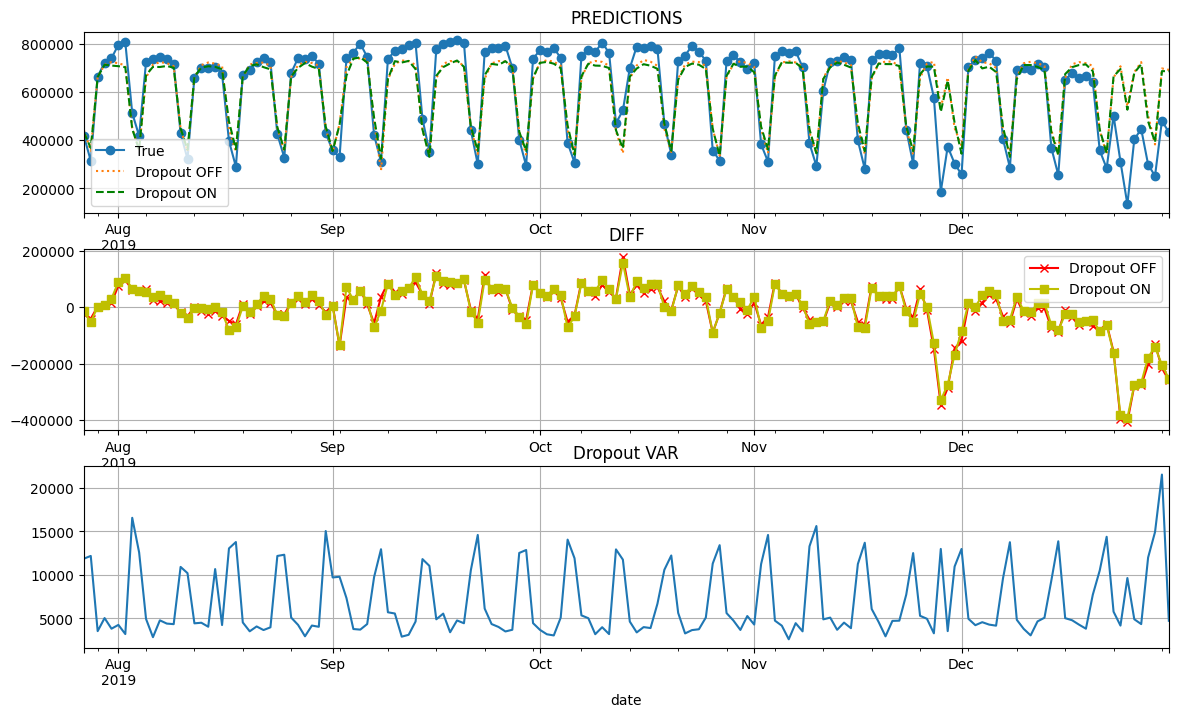

In [65]:
y_true = mulvar_test['rail'].iloc[frame_len:] * 1e6
y_pred = pd.Series(np.ravel(mc_model.predict(test_ds)), y_true.index) * 1e6

mc_mean_pred = pd.Series(np.ravel(np.mean(preds, axis=0)), y_true.index) * 1e6
mc_var_pred  = pd.Series(np.ravel(np.var(preds, axis=0)), y_true.index) * 1e6

fig, ax = plt.subplots(3, 1, figsize=(14, 8))

ax[0].set_title('PREDICTIONS')
y_true.plot(ax=ax[0], marker='o', label='True', legend=True, grid=True)
y_pred.plot(ax=ax[0], style=':', label='Dropout OFF', legend=True)
mc_mean_pred.plot(ax=ax[0], style='--', c='g', label='Dropout ON', legend=True)
ax[0].grid()

ax[1].set_title('DIFF')
(y_true - y_pred).plot(ax=ax[1], marker='x', c='r', label='Dropout OFF', legend=True, grid=True)
(y_true - mc_mean_pred).plot(ax=ax[1], marker='s', c='y', label='Dropout ON', legend=True)
ax[1].grid()

ax[2].set_title('Dropout VAR')
mc_var_pred.plot(ax=ax[2], grid=True)


In [66]:
mape_mc = ((y_true - mc_mean_pred) / y_true).abs().mean()
mape_mc

np.float32(0.15097521)

### batch normalization между RNN layer-ите

In [67]:
bn_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),

    tf.keras.layers.SimpleRNN(64, return_sequences=True, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('tanh'),

    tf.keras.layers.SimpleRNN(32, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('tanh'),

    tf.keras.layers.Dense(1)
])

bn_model.compile(loss=tf.keras.losses.Huber(), optimizer='adam', metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, restore_best_weights=True)]
bn_model.fit(train_ds, epochs=100, validation_data=(test_ds), callbacks=callbacks)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.1193 - mae: 0.3946 - val_loss: 0.1336 - val_mae: 0.4050
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0176 - mae: 0.1433 - val_loss: 0.0410 - val_mae: 0.2259
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0115 - mae: 0.1129 - val_loss: 0.0336 - val_mae: 0.1964
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0115 - mae: 0.1132 - val_loss: 0.0137 - val_mae: 0.1284
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0091 - mae: 0.1016 - val_loss: 0.0230 - val_mae: 0.1718
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0090 - mae: 0.0984 - val_loss: 0.0231 - val_mae: 0.1602
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0101 - mae: 0.1098 - val_loss: 0.0316 - val_mae: 0.2012
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0095 - mae: 0.1014 - val_loss: 0.0158 - val_mae: 0.1287
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - lo

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step


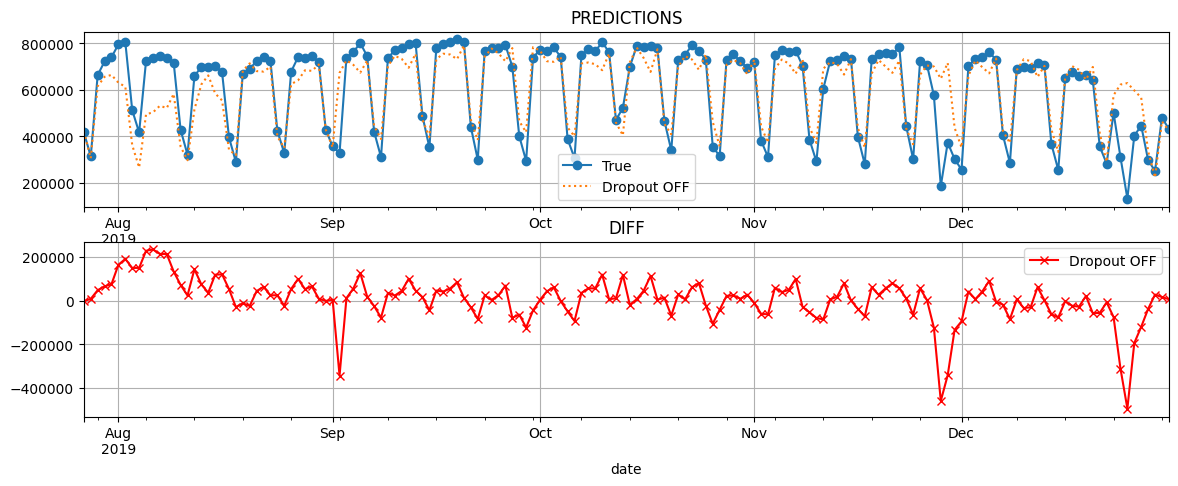

In [68]:
y_true = mulvar_test['rail'].iloc[frame_len:] * 1e6
y_pred = pd.Series(np.ravel(bn_model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))

ax[0].set_title('PREDICTIONS')
y_true.plot(ax=ax[0], marker='o', label='True', legend=True, grid=True)
y_pred.plot(ax=ax[0], style=':', label='Dropout OFF', legend=True)
ax[0].grid()

ax[1].set_title('DIFF')
(y_true - y_pred).plot(ax=ax[1], marker='x', c='r', label='Dropout OFF', legend=True)
ax[1].grid()

In [69]:
mape_bn = ((y_true - y_pred) / y_true).abs().mean()
mape_bn

np.float32(0.16040772)

### layer normalization

#### между RNN layer-ите

In [70]:
ln_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),

    tf.keras.layers.SimpleRNN(64, return_sequences=True, activation=None),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.Activation('tanh'),

    tf.keras.layers.SimpleRNN(32, activation=None),
    tf.keras.layers.LayerNormalization(),
    tf.keras.layers.Activation('tanh'),

    tf.keras.layers.Dense(1)
])

ln_model.compile(loss=tf.keras.losses.Huber(), optimizer='adam', metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, restore_best_weights=True)]
ln_model.fit(train_ds, epochs=100, validation_data=(test_ds), callbacks=callbacks)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.0367 - mae: 0.1835 - val_loss: 0.0157 - val_mae: 0.1578
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0124 - mae: 0.1340 - val_loss: 0.0094 - val_mae: 0.1035
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0055 - mae: 0.0737 - val_loss: 0.0074 - val_mae: 0.0704
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0046 - mae: 0.0625 - val_loss: 0.0070 - val_mae: 0.0681
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0044 - mae: 0.0590 - val_loss: 0.0063 - val_mae: 0.0633
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0045 - mae: 0.0618 - val_loss: 0.0064 - val_mae: 0.0664
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0043 - mae: 0.0596 - val_loss: 0.0060 - val_mae: 0.0638
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0051 - mae: 0.0671 - val_loss: 0.0063 - val_mae: 0.0637
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - lo

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step WARNING:tensorflow:5 out of the last 310 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x748353bf80e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


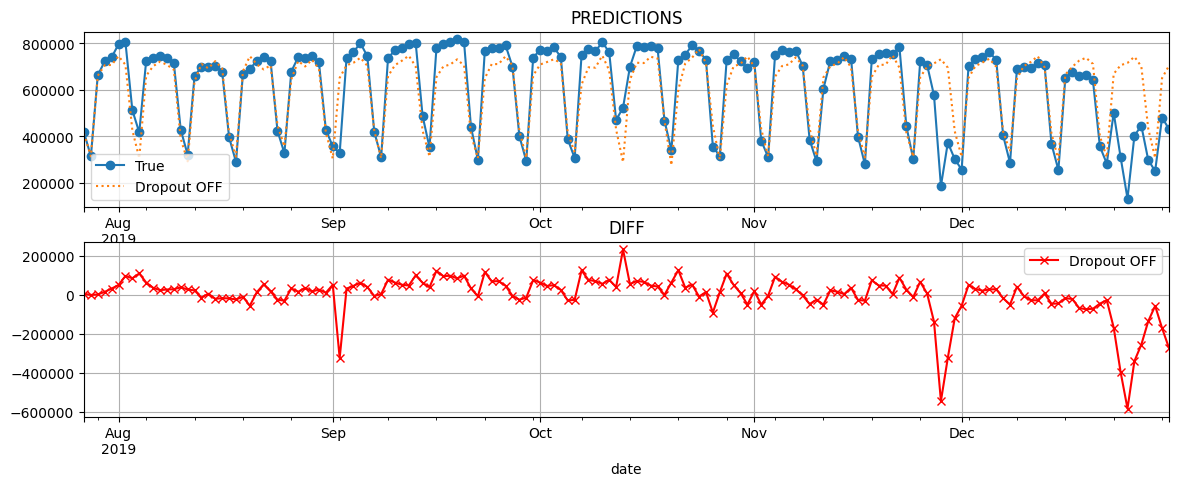

In [71]:
y_true = mulvar_test['rail'].iloc[frame_len:] * 1e6
y_pred = pd.Series(np.ravel(ln_model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))

ax[0].set_title('PREDICTIONS')
y_true.plot(ax=ax[0], marker='o', label='True', legend=True, grid=True)
y_pred.plot(ax=ax[0], style=':', label='Dropout OFF', legend=True)
ax[0].grid()

ax[1].set_title('DIFF')
(y_true - y_pred).plot(ax=ax[1], marker='x', c='r', label='Dropout OFF', legend=True)
ax[1].grid()

In [72]:
mape_ln = ((y_true - y_pred) / y_true).abs().mean()
mape_ln

np.float32(0.15870082)

#### LN RNN Cell

In [73]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units, activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [74]:
ln_cell_model = tf.keras.Sequential([
    tf.keras.layers.Input([None, 5]),
    tf.keras.layers.RNN(LNSimpleRNNCell(64), return_sequences=True),
    tf.keras.layers.RNN(LNSimpleRNNCell(32)),
    tf.keras.layers.Dense(1)
])

ln_cell_model.compile(loss=tf.keras.losses.Huber(), optimizer='adam', metrics=['mae'])
callbacks = [tf.keras.callbacks.EarlyStopping(patience=14, restore_best_weights=True)]
ln_cell_model.fit(train_ds, epochs=100, validation_data=(test_ds), callbacks=callbacks)

Epoch 1/100


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0351 - mae: 0.1757 - val_loss: 0.0056 - val_mae: 0.0698
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0048 - mae: 0.0639 - val_loss: 0.0046 - val_mae: 0.0585
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0037 - mae: 0.0561 - val_loss: 0.0042 - val_mae: 0.0551
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0029 - mae: 0.0494 - val_loss: 0.0034 - val_mae: 0.0491
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0024 - mae: 0.0462 - val_loss: 0.0028 - val_mae: 0.0440
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0021 - mae: 0.0436 - val_loss: 0.0027 - val_mae: 0.0458
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0019 - mae: 0.0415 - val_loss: 0.0021 - val_mae: 0.0441
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0018 - mae: 0.0414 - val_loss: 0.0020 - val_mae: 0.0416
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0017 -

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step


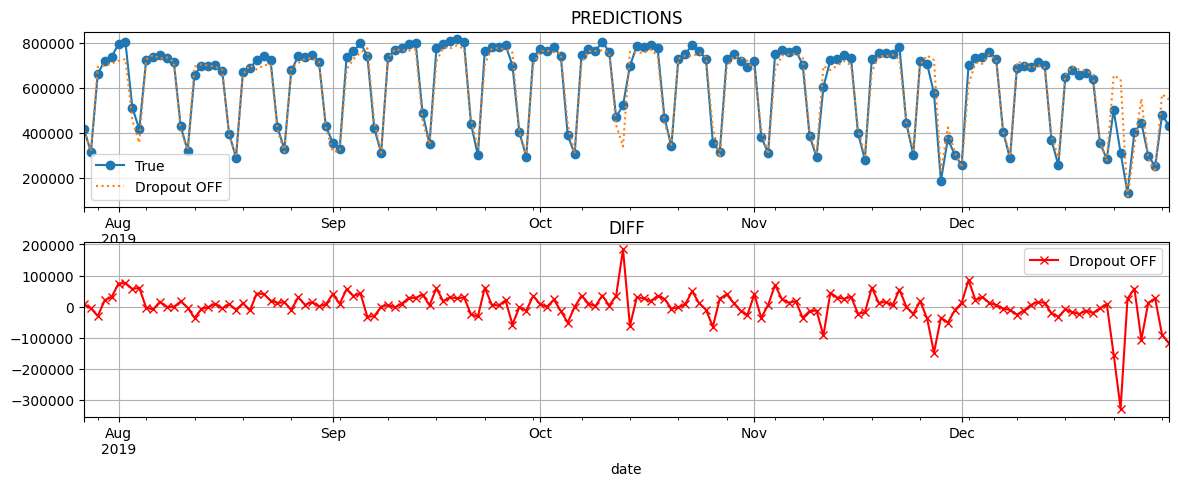

In [75]:
y_true = mulvar_test['rail'].iloc[frame_len:] * 1e6
y_pred = pd.Series(np.ravel(ln_cell_model.predict(test_ds)), y_true.index) * 1e6

fig, ax = plt.subplots(2, 1, figsize=(14, 5))

ax[0].set_title('PREDICTIONS')
y_true.plot(ax=ax[0], marker='o', label='True', legend=True, grid=True)
y_pred.plot(ax=ax[0], style=':', label='Dropout OFF', legend=True)
ax[0].grid()

ax[1].set_title('DIFF')
(y_true - y_pred).plot(ax=ax[1], marker='x', c='r', label='Dropout OFF', legend=True)
ax[1].grid()

In [76]:
mape_ln_cell = ((y_true - y_pred) / y_true).abs().mean()
mape_ln_cell

np.float32(0.05820948)

### Results

In [77]:
pd.Series([mape_mc, mape_bn, mape_ln, mape_ln_cell], 
          ['MCDropout', 'BatchNormalization', 'LayerNormalization', 'LayerNormalizationCell'], name='MAPE')

MCDropout                 0.150975
BatchNormalization        0.160408
LayerNormalization        0.158701
LayerNormalizationCell    0.058209
Name: MAPE, dtype: float32